In [40]:
import sys
sys.path.append("C:/Users/rozhkova_as/Desktop/Rozhkova/Projects/DL/VAE_Python")  # путь к VAE.py

import torch.optim as optim
from VAE import VAE, KLDLoss, VAEConfig
from StepByStep import VAEStepByStep
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from tensorboard.backend.event_processing import event_accumulator
import os
import re
from PIL import Image
import io
from IPython.display import HTML

In [2]:
latent_dim = 64
config = VAEConfig(latent_dim = latent_dim)
model = VAE(config)
loss_fn = KLDLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

sbs = VAEStepByStep(model, loss_fn=loss_fn, optimizer=optimizer)

train_data_folder = 'C:\\Users\\rozhkova_as\\Desktop\\Rozhkova\\Projects\\DL\\data\\mvtec_anomaly_detection\\screw\\train'
test_data_folder = 'C:\\Users\\rozhkova_as\\Desktop\\Rozhkova\\Projects\\DL\\data\\mvtec_anomaly_detection\\screw\\test'
sbs.prepare_data(train_data_folder, test_data_folder, batch_size=32)
# sbs.set_tensorboard(f"exp_{latent_dim}", folder = 'runs\\model_23012025')

num_epochs = 80
train_losses=sbs.train(n_epochs=num_epochs)

Epoch: 1 | Loss: 42190.1943 | Reconstruction Loss: 40622.6154 | KL Divergence: 1567.57920871
Epoch: 2 | Loss: 12534.4894 | Reconstruction Loss: 11872.6109 | KL Divergence: 661.87839661
Epoch: 3 | Loss: 7747.9854 | Reconstruction Loss: 7500.9036 | KL Divergence: 247.08188171
Epoch: 4 | Loss: 5327.2291 | Reconstruction Loss: 5103.1698 | KL Divergence: 224.05927429
Epoch: 5 | Loss: 4238.2938 | Reconstruction Loss: 4051.4832 | KL Divergence: 186.81062164
Epoch: 6 | Loss: 3644.8322 | Reconstruction Loss: 3446.3020 | KL Divergence: 198.53018951
Epoch: 7 | Loss: 3239.6104 | Reconstruction Loss: 3036.3607 | KL Divergence: 203.24964600
Epoch: 8 | Loss: 2892.6658 | Reconstruction Loss: 2689.2029 | KL Divergence: 203.46285400
Epoch: 9 | Loss: 2573.4576 | Reconstruction Loss: 2375.0250 | KL Divergence: 198.43262329
Epoch: 10 | Loss: 2367.9034 | Reconstruction Loss: 2176.5343 | KL Divergence: 191.36909180
Epoch: 11 | Loss: 2248.4089 | Reconstruction Loss: 2058.9451 | KL Divergence: 189.46381378
Epo

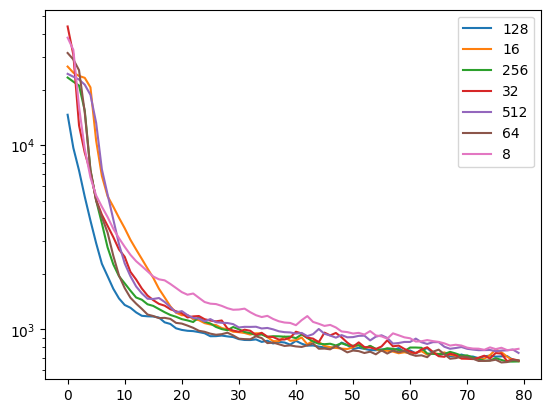

In [7]:
log_dir = "C:\\Users\\rozhkova_as\\Desktop\\Rozhkova\\Projects\\DL\\VAE_Python\\runs\\Latent_Dim"  # путь к логам
for run in os.listdir(log_dir):
    path = os.path.join(log_dir, run)

    ea = event_accumulator.EventAccumulator(path)

    ea.Reload()

    match = re.search(r'exp_lat_dim_(\d+)', path)
    if match:
        label = int(match.group(1))

    if 'Loss/train' in ea.Tags()['scalars']:
        events = ea.Scalars("Loss/train")
        steps = [e.step for e in events]
        values = [e.value for e in events]

        plt.plot(steps,values, label = label)

plt.yscale('log')
plt.legend()
plt.show()

In [ ]:
for run in os.listdir(log_dir):
    path = os.path.join(log_dir, run)

    ea = event_accumulator.EventAccumulator(path)
    ea.Reload()

    if 'Images/test_image' in ea.Tags()['images']:
        events = ea.Images("Images/test_image")
        
        fig, ax = plt.subplots()
        ax.axis('off')

        first_img = Image.open(io.BytesIO(events[0].encoded_image_string))
        im = ax.imshow(first_img)
        

        def update(i):
            img = Image.open(io.BytesIO(events[i].encoded_image_string))
            im.set_data(img)
            ax.set_title(f"{run} | step {events[i].step}")
            return [im]
        
        anim = animation.FuncAnimation(
            fig,
            update,
            frames=len(events),
            interval=300
        )

        plt.close()

        display(HTML(anim.to_jshtml()))
